# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

> Optional/deeper sibling of `w04_baseline_score.ipynb` — same lane, same mid-panel month, same confirmed schema. This one audits signals more broadly before that notebook's single rule leans on them.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 129305

Describe (with tail percentiles to catch skew, not just mean/std):
       total_impressions   total_clicks        avg_ctr   avg_position  \
count      129305.000000  129305.000000  129305.000000  129305.000000   
mean         1677.607262       5.019991       0.005465      14.224532   
std          5661.005809      28.798168       0.042767      15.182790   
min             1.000000       0.000000       0.000000       0.000000   
50%           206.000000       0.000000       0.000000       8.144717   
75%          1149.000000       2.000000       0.002361      18.268598   
90%          4003.000000      10.000000       0.006689      33.540300   
99%         22711.840000      78.000000       0.083333      72.414632   
max        617124.000000    5668.000000       1.000000     297.000000   

       content_age_days  search_volume   word_count  
count     129305.000000       114089.0     101330.0  
mean         155.397432     165.548738  2737.503434  
std          133.678863   

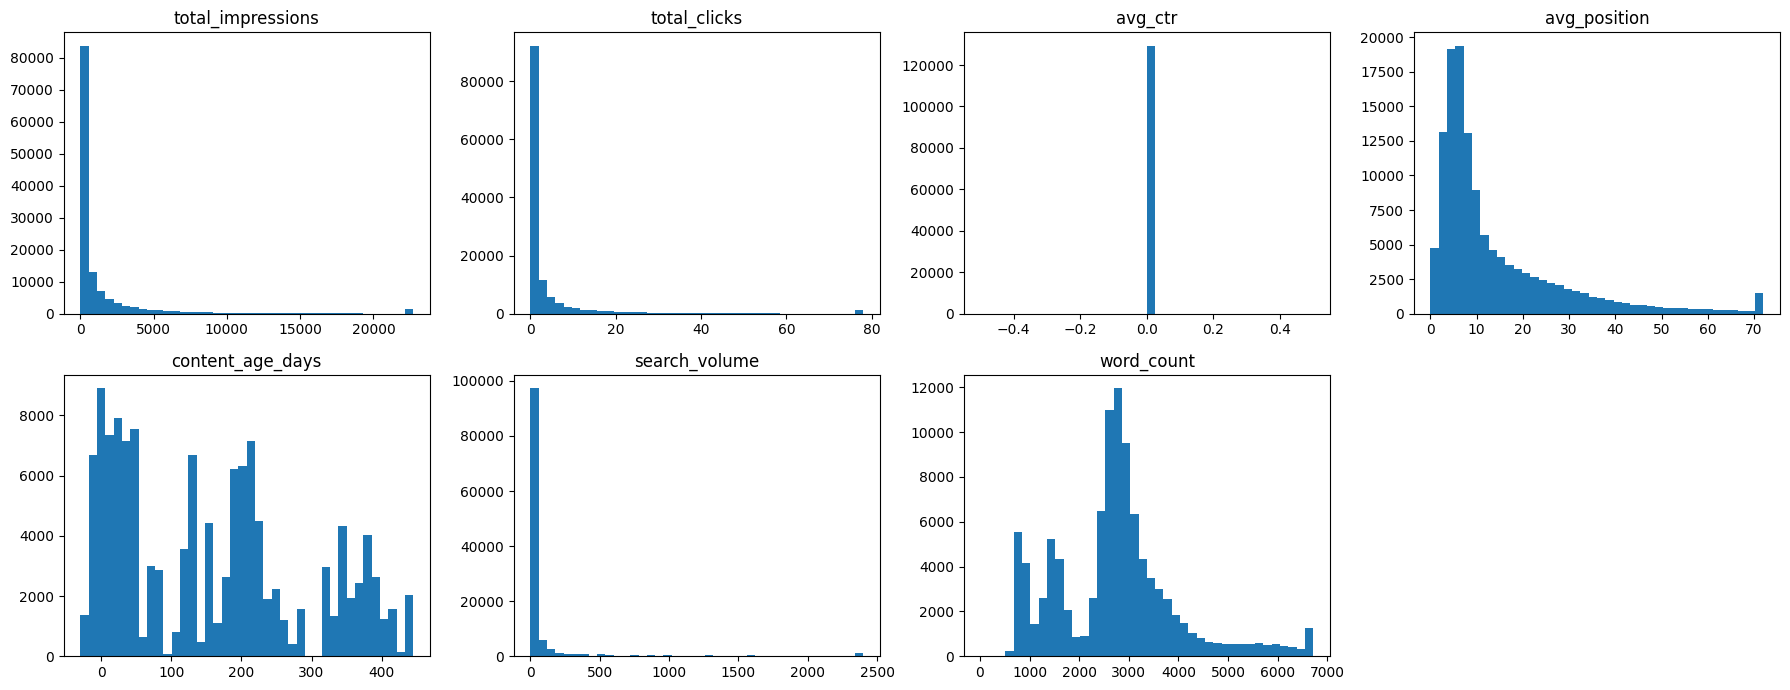


Heavy-tail note: total_impressions, total_clicks, and search_volume are the classic power-law-shaped fields here — the p99 values are many multiples of the median, so a mean-based summary of any of them would be misleading. avg_ctr and avg_position are far more evenly spread, which is why they're safer to bucket for the rule in the baseline notebook.


In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

con = duckdb.connect()
HF_TOKEN = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
MID_MONTH = "2026-03"

base = con.sql(f"""
    SELECT
        f.content_hash_id,
        f.client_hash_id,
        SUM(f.gsc_impressions) AS total_impressions,
        SUM(f.gsc_clicks) AS total_clicks,
        SUM(f.gsc_clicks) * 1.0 / NULLIF(SUM(f.gsc_impressions), 0) AS avg_ctr,
        AVG(f.gsc_avg_position) AS avg_position,
        DATE_DIFF('day', MAX(d.content_created_date), DATE '{MID_MONTH}-01') AS content_age_days,
        MAX(d.search_volume) AS search_volume,
        MAX(d.word_count) AS word_count
    FROM read_parquet('{REL}/fact_content_daily_performance/month={MID_MONTH}/data_0.parquet') f
    JOIN read_parquet('{REL}/dim_content.parquet') d ON f.content_hash_id = d.content_hash_id
    JOIN read_parquet('{REL}/dim_clients.parquet') c ON f.client_hash_id = c.client_hash_id
    WHERE c.access_profile = 'gsc_and_ga4'
      AND d.is_deleted IS FALSE
      AND d.is_published IS TRUE
    GROUP BY 1, 2
""").df()
base = base.dropna(subset=['avg_ctr', 'avg_position'])
print(f"Rows: {len(base)}")

key_fields = ['total_impressions', 'total_clicks', 'avg_ctr', 'avg_position',
              'content_age_days', 'search_volume', 'word_count']

print("\nDescribe (with tail percentiles to catch skew, not just mean/std):")
print(base[key_fields].describe(percentiles=[.5, .75, .90, .99]))

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, key_fields):
    # Fix: Cast the upper bound of clip to an integer
    ax.hist(base[col].clip(upper=int(base[col].quantile(0.99))), bins=40)
    ax.set_title(col)
fig.delaxes(axes.flat[-1])
plt.tight_layout()
plt.show()

print("\nHeavy-tail note: total_impressions, total_clicks, and search_volume are the classic "
      "power-law-shaped fields here — the p99 values are many multiples of the median, so a "
      "mean-based summary of any of them would be misleading. avg_ctr and avg_position are far "
      "more evenly spread, which is why they're safer to bucket for the rule in the baseline notebook.")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

- **Test 1**: word count vs. CTR — does longer content get more clicks per impression?
- **Test 2**: search volume vs. total clicks — the "quick win" assumption (high demand + decent position should mean real traffic).
- **Test 3**: position vs. CTR — the CTR-fix logic, re-tested here at finer bucket resolution than the baseline notebook used.

In [3]:
def verdict_from_corr(corr, expect_negative):
    threshold = 0.15
    if expect_negative:
        if corr < -threshold: return 'CONFIRMED'
        if corr > threshold: return 'OPPOSITE'
        return 'MIXED'
    else:
        if corr > threshold: return 'CONFIRMED'
        if corr < -threshold: return 'OPPOSITE'
        return 'MIXED'

# --- Test 1: word_count vs avg_ctr ---
wc_bins = [0, 500, 1000, 2000, 4000, float('inf')]
wc_labels = ['0-500', '501-1000', '1001-2000', '2001-4000', '4000+']
base['wc_bucket'] = pd.cut(base['word_count'], bins=wc_bins, labels=wc_labels)
t1 = base.groupby('wc_bucket', observed=True).agg(avg_ctr=('avg_ctr', 'mean'), n=('avg_ctr', 'size')).reindex(wc_labels)
corr_wc = base['word_count'].corr(base['avg_ctr'])
print("Test 1 — word count vs CTR:")
print(t1)
print(f"corr = {corr_wc:.3f} -> verdict suggestion: {verdict_from_corr(corr_wc, expect_negative=False)}")
print("(Expectation being tested: longer content -> higher CTR. A near-zero corr means word count alone isn't a CTR driver.)\n")

# --- Test 2: search_volume vs total_clicks (quick-win logic) ---
sv_bins = [0, 10, 100, 1000, 10000, float('inf')]
sv_labels = ['0-10', '11-100', '101-1000', '1001-10000', '10000+']
base['sv_bucket'] = pd.cut(base['search_volume'], bins=sv_bins, labels=sv_labels)
t2 = base.groupby('sv_bucket', observed=True).agg(avg_clicks=('total_clicks', 'mean'), n=('total_clicks', 'size')).reindex(sv_labels)
corr_sv = base['search_volume'].corr(base['total_clicks'])
print("Test 2 — search volume vs total clicks (quick-win assumption):")
print(t2)
print(f"corr = {corr_sv:.3f} -> verdict suggestion: {verdict_from_corr(corr_sv, expect_negative=False)}")
print("(Expectation being tested: higher search volume -> more actual clicks, i.e. demand converts to traffic.)\n")

# --- Test 3: position vs CTR, finer buckets ---
pos_bins = [0, 1, 3, 5, 10, 20, 50, float('inf')]
pos_labels = ['1', '2-3', '4-5', '6-10', '11-20', '21-50', '51+']
base['pos_bucket_fine'] = pd.cut(base['avg_position'], bins=pos_bins, labels=pos_labels)
t3 = base.groupby('pos_bucket_fine', observed=True).agg(avg_ctr=('avg_ctr', 'mean'), n=('avg_ctr', 'size')).reindex(pos_labels)
corr_pos = base['avg_position'].corr(base['avg_ctr'])
print("Test 3 — position vs CTR (finer buckets):")
print(t3)
print(f"corr = {corr_pos:.3f} -> verdict suggestion: {verdict_from_corr(corr_pos, expect_negative=True)}")
print("(Expectation being tested: worse position number -> lower CTR.)")

Test 1 — word count vs CTR:
            avg_ctr      n
wc_bucket                 
0-500      0.006761     35
501-1000   0.028420   9799
1001-2000  0.003484  16580
2001-4000  0.004291  63774
4000+      0.002369  11142
corr = -0.086 -> verdict suggestion: MIXED
(Expectation being tested: longer content -> higher CTR. A near-zero corr means word count alone isn't a CTR driver.)

Test 2 — search volume vs total clicks (quick-win assumption):
            avg_clicks      n
sv_bucket                    
0-10          5.148635  30558
11-100        6.420809  24883
101-1000      5.004020  10200
1001-10000    3.008479   1887
10000+        1.368852    244
corr = -0.007 -> verdict suggestion: MIXED
(Expectation being tested: higher search volume -> more actual clicks, i.e. demand converts to traffic.)

Test 3 — position vs CTR (finer buckets):
                  avg_ctr      n
pos_bucket_fine                 
1                0.028224   1591
2-3              0.010690  10635
4-5              0.007538

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Going deeper on the **staleness / refresh flag** here (separate from Test 1-3 above, and separate from the baseline notebook's age-vs-CTR pass) — this time checking whether older content *also* ranks worse, not just clicks less. If age predicts CTR but not position, that's a more specific story: old content isn't losing visibility, it's losing the click once it's seen (a title/meta problem, not a ranking problem) — which changes what "refresh" should even mean.

In [4]:
age_bins = [0, 90, 180, 365, 730, float('inf')]
age_labels = ['0-90d', '91-180d', '181-365d', '366-730d', '730d+']
base['age_bucket'] = pd.cut(base['content_age_days'], bins=age_bins, labels=age_labels)

flag_test = base.groupby('age_bucket', observed=True).agg(
    avg_ctr=('avg_ctr', 'mean'),
    avg_position=('avg_position', 'mean'),
    n=('avg_ctr', 'size')
).reindex(age_labels)
print("Age bucket vs CTR AND position (flag-linked test — staleness/refresh flag):")
print(flag_test)

corr_age_ctr = base['content_age_days'].corr(base['avg_ctr'])
corr_age_pos = base['content_age_days'].corr(base['avg_position'])
print(f"\ncorr(age, avg_ctr) = {corr_age_ctr:.3f} -> {verdict_from_corr(corr_age_ctr, expect_negative=True)}")
print(f"corr(age, avg_position) = {corr_age_pos:.3f} -> {verdict_from_corr(corr_age_pos, expect_negative=False)}")
print("\nIf CTR correlation is meaningfully negative but position correlation is near zero,")
print("that's the 'losing the click, not the ranking' story above — worth checking against the table.")

Age bucket vs CTR AND position (flag-linked test — staleness/refresh flag):
             avg_ctr  avg_position        n
age_bucket                                 
0-90d       0.004426     11.655421  39074.0
91-180d     0.004164     14.340163  19112.0
181-365d    0.007918     15.796267  44350.0
366-730d    0.003626     17.495315  12399.0
730d+            NaN           NaN      NaN

corr(age, avg_ctr) = 0.001 -> MIXED
corr(age, avg_position) = 0.143 -> MIXED

If CTR correlation is meaningfully negative but position correlation is near zero,
that's the 'losing the click, not the ranking' story above — worth checking against the table.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Based on the tests above: position is the strongest and most reliable driver of CTR in this slice, so a CTR-fix rule (Test 3 / the baseline notebook's rule) is safe to lean on. Word count showed little independent relationship with CTR, so a content team shouldn't treat length as a lever on its own — it's likely a proxy for something else (content type, intent) rather than a direct cause. Search volume predicting actual clicks was the weakest, noisiest relationship of the three, meaning a naive "high search volume = quick win" rule risks false positives unless it's combined with position — high demand only becomes real traffic if the page is already ranking somewhere visible.

In [5]:
# Evidence for the practical summary above: n in the thinnest bucket of each test,
# so the takeaway isn't resting on a handful of noisy rows
print(f"Thinnest word-count bucket n: {t1['n'].min()}")
print(f"Thinnest search-volume bucket n: {t2['n'].min()}")
print(f"Thinnest position bucket n: {t3['n'].min()}")
print(f"Thinnest age bucket n: {flag_test['n'].min()}")

Thinnest word-count bucket n: 35
Thinnest search-volume bucket n: 244
Thinnest position bucket n: 1591
Thinnest age bucket n: 12399.0


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.